In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, NNConv, CGConv, global_max_pool, GCNConv, GATConv, GATv2Conv
from torch_geometric.nn import SAGPooling, ASAPooling, GraphNorm

import graphy_gnn

/home/amutua/inverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal valu

## Data Prep

These are all the graphs

In [ ]:
full_train_graphs = torch.load("Final_Dataset/gnn graphs/train_graphs.pt", weights_only=False)
full_val_graphs = torch.load("Final_Dataset/gnn graphs/val_graphs.pt", weights_only=False)
full_test_graphs = torch.load("Final_Dataset/gnn graphs/test_graphs.pt", weights_only=False)

train_loader = DataLoader(full_train_graphs, batch_size=1, shuffle=True)
val_loader = DataLoader(full_val_graphs, batch_size=1, shuffle=False)
test_loader = DataLoader(full_test_graphs, batch_size=1, shuffle=False)

These graphs are just a fraction of the full graphs

In [2]:
trimmed_train_graphs = torch.load("Final_Dataset/gnn graphs/trimmed_train_graphs.pt", weights_only=False)
trimmed_val_graphs = torch.load("Final_Dataset/gnn graphs/trimmed_val_graphs.pt", weights_only=False)
trimmed_test_graphs = torch.load("Final_Dataset/gnn graphs/trimmed_test_graphs.pt", weights_only=False)

train_loader = DataLoader(trimmed_train_graphs, batch_size=1, shuffle=True)
val_loader = DataLoader(trimmed_val_graphs, batch_size=1, shuffle=False)
test_loader = DataLoader(trimmed_test_graphs, batch_size=1, shuffle=False)

These are the graphs of $BN$, $InSe$, $GaSe$, and Black Phosphorus

In [15]:
well_distributed_train_graphs = torch.load("Final_Dataset/gnn graphs/well_distributed_train_graphs.pt", weights_only=False)
well_distributed_val_graphs = torch.load("Final_Dataset/gnn graphs/well_distributed_val_graphs.pt", weights_only=False)
well_distributed_test_graphs = torch.load("Final_Dataset/gnn graphs/well_distributed_test_graphs.pt", weights_only=False)


train_loader = DataLoader(well_distributed_train_graphs, batch_size=1, shuffle=True)
val_loader = DataLoader(well_distributed_val_graphs, batch_size=1, shuffle=True)
test_loader = DataLoader(well_distributed_test_graphs, batch_size=1, shuffle=True)

In [3]:
for i in well_distributed_train_graphs:
    print(i)
    break

Data(x=[14, 27], edge_index=[2, 91], edge_attr=[91, 14], y=[1], u=[1, 14], fe=[1], ids=[2], ratios=[2])


In [5]:
# Use data size to determine model architecture
NODE_DIM =well_distributed_train_graphs[0].x.shape[1] # 27
EDGE_DIM =well_distributed_train_graphs[0].edge_attr.shape[1] # 14
HIDDEN_DIM = 128
EMBED_DIM = 16
U_DIM =well_distributed_train_graphs[0].u.shape[1] # 14

# The GNN Model

## Training and evaluation functions

In [16]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from tqdm.auto import tqdm

def evaluate(model, loader, loss_fn, device):
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for data in tqdm(loader, leave=False):
            data = data.to(device)
            out = model(data)
            if torch.isnan(out).any():
                print("Found an NaN value")
                break

            
            loss = loss_fn(out.view(-1), data.y.view(-1))

            eval_loss += loss.item() * data.num_graphs
    return eval_loss / len(loader.dataset)

def train(model, train_loader, loss_fn, device, optimizer):
    model.train()
    train_loss = 0
    # anomalies = []
    # idx = 0

    for data in tqdm(train_loader, leave=False):
        optimizer.zero_grad()

        data = data.to(device)
        out = model(data)

        if torch.isnan(out).any():
            print("Found an NaN value")
            break

        '''if out > 50.0:
            # Flag this structures as unstable
            anomalies.append((idx,out))'''
        
        loss = loss_fn(out.view(-1), data.y.view(-1))
        # idx+=1

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * data.num_graphs

    # print(anomalies)

    return train_loss / len(train_loader.dataset)

def predict(model, loader, device, visualize=False):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for data in tqdm(loader, leave=False):
            data = data.to(device)
            out = model(data)
            if torch.isnan(out).any():
                print("Found an NaN value")
                break
            predictions.append(out.view(-1).cpu().numpy())

            # Only collect targets if they exist
            if hasattr(data, "y") and data.y is not None:
                actuals.append(data.y.view(-1).cpu().numpy())

    if actuals:
        actuals = np.concatenate(actuals, axis=0).flatten()
    else:
        actuals = None

    predictions = np.concatenate(predictions, axis=0).flatten()

    '''return predictions, actuals

    prediction = np.concatenate(predictions, axis=0).flatten()
    actual = np.concatenate(actuals, axis=0).flatten()'''

    if visualize:
        fig, axs = plt.subplots(3, 1, figsize=(10, 15))

        # model values
        predicted_values = predictions
        actual_values = actuals
        if len(predicted_values) > 300:
            predicted_values = predicted_values[-300:]
            actual_values = actual_values[-300:]
        
        residuals = actual_values - predicted_values


        axs[0].scatter(actual_values, predicted_values )
        axs[0].plot(actual_values, actual_values, c="black")
        axs[0].set_xlabel('Actual Band Gaps(eV)')
        axs[0].set_ylabel('Predicted Band Gaps(eV)')
        axs[0].set_title('Actual vs Predicted Band Gap Values')
        axs[0].legend()

        axs[1].plot(actual_values, label='Actual Values', marker='o')
        axs[1].plot(predicted_values, label='Predicted Values', marker='o')
        axs[1].set_xlabel('Samples')
        axs[1].set_ylabel('Band gap(eV)')
        axs[1].set_title('Actual vs Predicted Band Gap Values')
        axs[1].legend()

        axs[2].scatter(predicted_values, residuals )
        axs[2].axhline(0, color='red', linestyle='--')
        axs[2].set_xlabel('Predicted Band Gaps(eV)')
        axs[2].set_ylabel('Residuals (Actual - Predicted)')
        axs[2].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

    return predictions, actuals



def training_validating_testing(model, loss_fn, epochs, device, predicting=False):
    # PARAMETERIZE THE MODEL
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    # TRAIN AND VALIDATE MODEL
    print("Training and Validating Model")

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs+1):
        t_loss = train(model, train_loader, loss_fn, device, optimizer)
        train_losses.append(t_loss)

        v_loss = evaluate(model, val_loader, loss_fn, device)
        val_losses.append(v_loss)

        # scheduler.step()
        print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

    print("Testing Model")

    test_loss = evaluate(model, test_loader, loss_fn, device)
    print(f'Test Loss: {test_loss:.4f}')


    # VISUALIZE METRICS

    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training  and Validation Loss')
    plt.legend()
    plt.show()

    if predicting:
        # Make Predictions
        print("Making Predictions")
        predicted, the_target = predict(model, test_loader,device, visualize=True)

        # ERROR ANALYSIS

        mae = mean_absolute_error(the_target, predicted)
        mse = mean_squared_error(the_target, predicted)
        r2 = r2_score(the_target, predicted)

        print(f'Mean Absolute Error: {mae:.4f}')
        print(f'Mean Squared Error: {mse:.4f}')
        print(f'R-squared: {r2:.4f}')
        

## Loss Functions

In [17]:
class WeightedMSELoss(nn.Module):
    def __init__(self, device):
        super().__init__()
        boundaries = np.linspace(0,2.5,10)

        # Fit the targets to the boundaries
        train_targets = [i.y for i in well_distributed_train_graphs] 
        the_targets = train_targets


        counts, edges = np.histogram(the_targets, bins=boundaries)
        counts = counts.astype(float) + 1.0
        weights = 1/counts
        
        self.weights = weights / weights.mean()
        self.boundaries = torch.tensor(boundaries, device=device)

    def forward(self, prediction, target):

        # Find which interval each target belongs to
        # self.boundaries.to(device=target.device)
        # self.weights.to(device=target.device)
        
        bin_indices = torch.bucketize(target.squeeze(-1), self.boundaries[1:-1])

        # Get weight for each target
        sample_weights = self.weights[bin_indices]

        # Squared error
        squared_error = (prediction.squeeze(-1) - target.squeeze(-1)) ** 2

        # Weighted MSE
        loss = (sample_weights * squared_error).sum() / sample_weights.sum()

        return loss

In [18]:
# Loss functions

class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))


class RelativeMSELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean(((y_pred-y_true)/ (y_true + 1e-8)) ** 2)


class SMAPELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        numerator = torch.abs(y_pred - y_true)
        denominator = (torch.abs(y_true) + torch.abs(y_pred))/2.0 + 1e-8
        return torch.mean(numerator/denominator)

## Models

### Model 0

Training and Validating Model


Epoch 001, Train Loss: 0.1193, Val Loss: 0.0960


Epoch 002, Train Loss: 0.0832, Val Loss: 0.0821


Epoch 003, Train Loss: 0.0798, Val Loss: 0.0824


Epoch 004, Train Loss: 0.0781, Val Loss: 0.0808


...

Epoch 007, Train Loss: 0.0732, Val Loss: 0.0779


Epoch 008, Train Loss: 0.0721, Val Loss: 0.0887


Epoch 009, Train Loss: 0.0719, Val Loss: 0.0776


Epoch 010, Train Loss: 0.0713, Val Loss: 0.0756
Testing Model


Test Loss: 0.0930


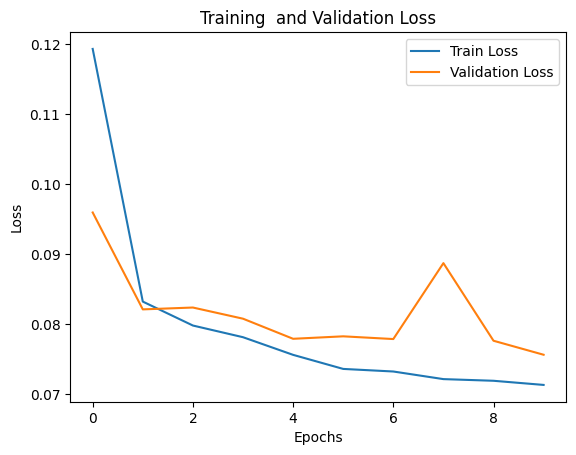

Making Predictions


/tmp/ipykernel_3094315/1509264483.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


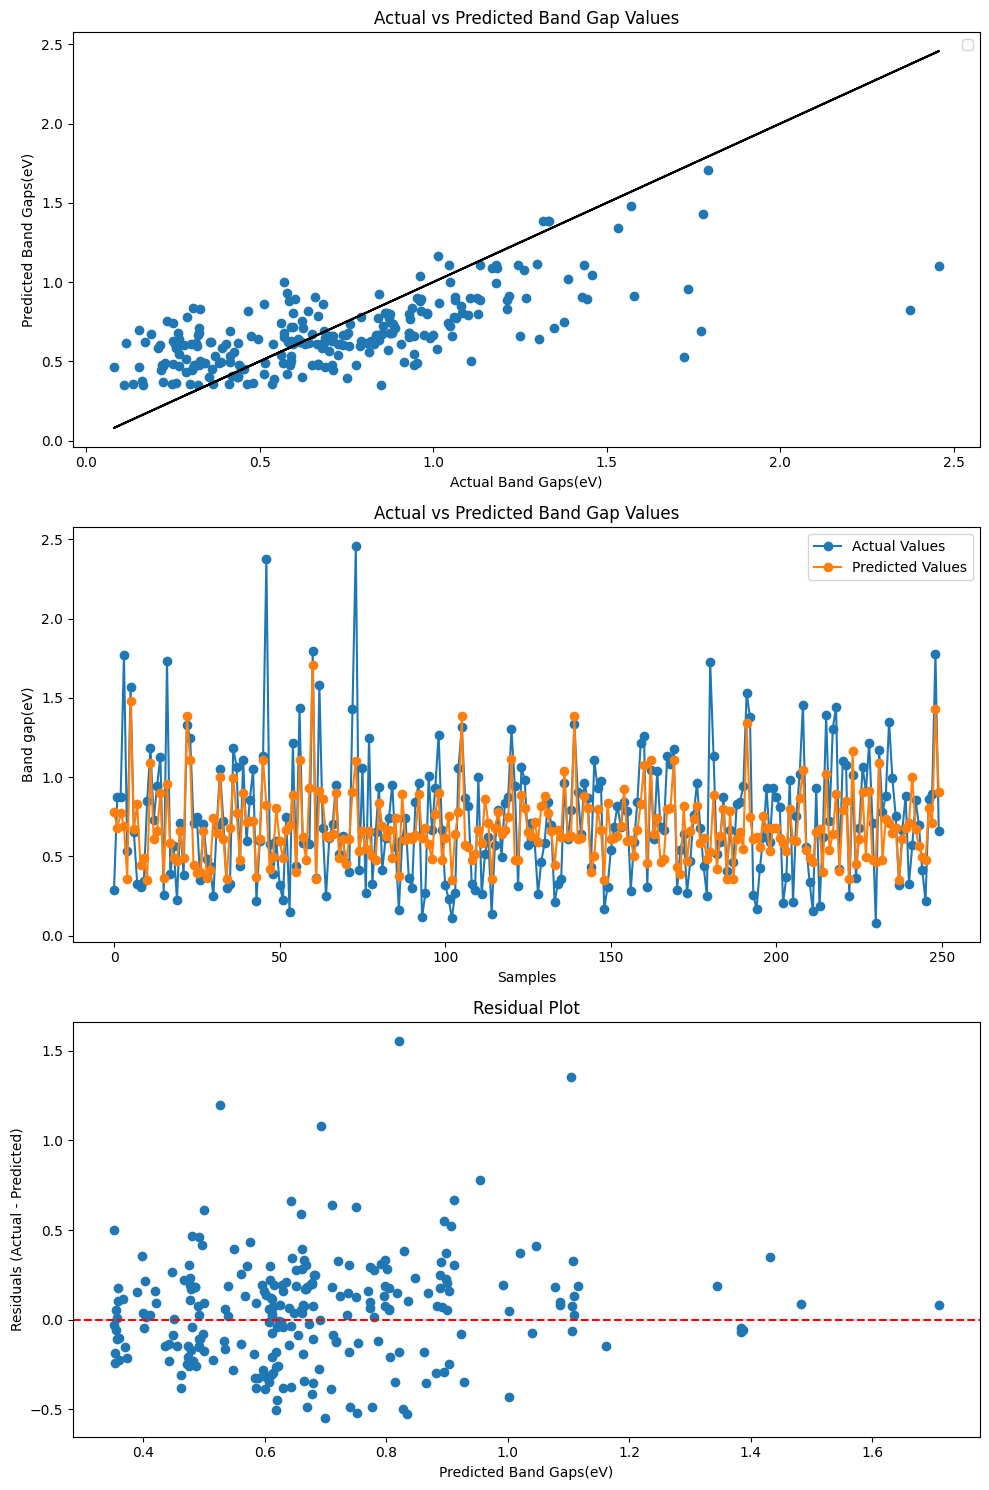

Mean Absolute Error: 0.2267
Mean Squared Error: 0.0930
R-squared: 0.4202


In [19]:
# Original Model
class GNNModel0(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, embed_dim):
        super().__init__()
        # ==============================
        # HANDLE NODES AND EDGES
        # ==============================

        # Edge NN maps edge_attr to weight matrix
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 32), nn.ReLU(),
            nn.Linear(32, node_dim * 16)
        )

        self.conv1 = NNConv(node_dim, 16, self.edge_nn, aggr='mean')

        # ===============================
        # HANDLE IDS 
        # ===============================

        self.element_embedding = nn.Embedding(118, embed_dim)

        # ===============================
        # COMBINE THEM ALL
        # ===============================

        self.seq_combine = nn.Sequential(
            nn.Linear(16 + embed_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    '''def get_u(self, the_ids, the_ratios):
        emb = self.element_embedding(the_ids)
        weighted_emb = emb * the_ratios.unsqueeze(1)
        return weighted_emb.sum(dim=0)'''

    def forward(self,data):
        x, edge_index, edge_attr, batch, u, idss, ratioss= (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u, data.ids, data.ratios
        )

        x, edge_attr, u = (F.normalize(x), F.normalize(edge_attr), F.normalize(u))
        # ==============================
        # HANDLE NODES AND EDGES
        # ==============================

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        # x = F.normalize(x)
        x = global_mean_pool(x, batch)

        # ===============================
        # HANDLE IDS 
        # ===============================
        ids_embed = self.element_embedding(idss)
        
        ratioss = ratioss.unsqueeze(1)    
        weighted_embed = ids_embed * ratioss

        # ids_ratios = global_mean_pool(weighted_embed, data.batch)
        # ids_ratios = torch.mean(weighted_embed, dim=0, keepdim=True)
        ids_ratios = torch.sum(weighted_embed, dim=0, keepdim=True)

        '''global_attr = self.get_u(idss.to(self.element_embedding.weight.device),
                                 ratioss.to(self.element_embedding.weight.device)
                                 ).expand(x.size(0), -1)'''

        # ===============================
        # COMBINE THEM ALL
        # ===============================
        
        x = torch.cat([x, ids_ratios], dim=1)
        x = self.seq_combine(x)
        # x = torch.clamp(x, min=0.0, max=2.5)
        # x = torch.sigmoid(x * 3.0)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model0 = GNNModel0(NODE_DIM, EDGE_DIM, HIDDEN_DIM, EMBED_DIM).to(device)
# loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = nn.HuberLoss()
loss_fn = WeightedMSELoss(device)
epochs = 10

training_validating_testing(model0, loss_fn, epochs, device, predicting=True)

### Model 1

Training and Validating Model


Epoch 001, Train Loss: 0.1238, Val Loss: 0.0935


Epoch 002, Train Loss: 0.0890, Val Loss: 0.0816


Epoch 003, Train Loss: 0.0879, Val Loss: 0.0968


Epoch 004, Train Loss: 0.0859, Val Loss: 0.0869


...

Epoch 007, Train Loss: 0.0802, Val Loss: 0.0961


Epoch 008, Train Loss: 0.0778, Val Loss: 0.1037


Epoch 009, Train Loss: 0.0767, Val Loss: 0.0834


Epoch 010, Train Loss: 0.0747, Val Loss: 0.0882
Testing Model


Test Loss: 0.0904


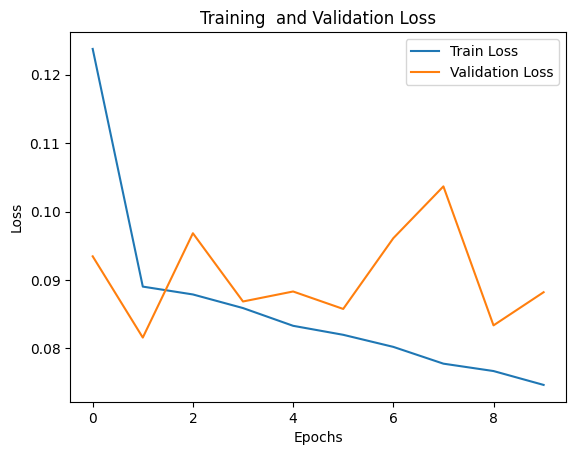

Making Predictions


/tmp/ipykernel_3094315/1509264483.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


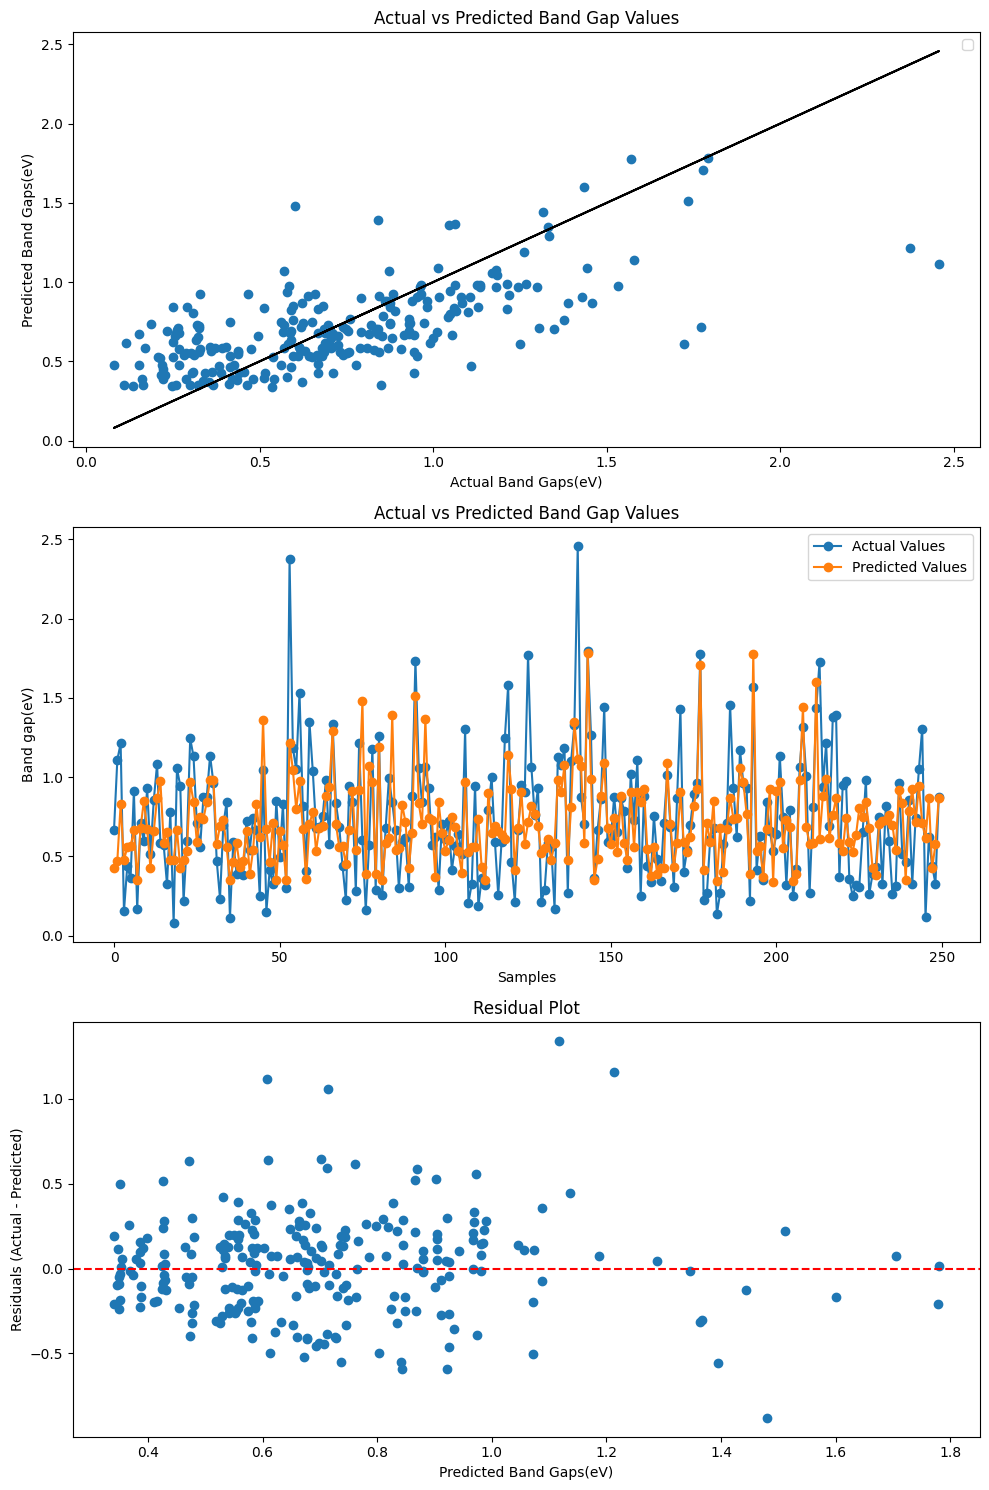

Mean Absolute Error: 0.2249
Mean Squared Error: 0.0904
R-squared: 0.4361


In [30]:
class GNNModel1(nn.Module):
    def __init__(self, node_dim, edge_dim, u_dim, hidden_dim):
        super().__init__()

        # =========================
        # HANDLE NODES AND EDGES
        # =========================
        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        self.conv_norm0 = GraphNorm(hidden_dim)
                
        # self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean')# , batch_norm=True)
        # self.conv_norm1 = GraphNorm(hidden_dim)

        # self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')# , batch_norm=True)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        # self.conv_norm2 = GraphNorm(hidden_dim)

        # self.asapool = ASAPooling(hidden_dim, ratio=0.5)
        # self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean', batch_norm=True)

        self.seq_nodes = nn.Sequential(
            nn.Linear(hidden_dim,64), nn.LeakyReLU(), 
            nn.Linear(64,32), nn.LeakyReLU(), 
            nn.Linear(32,16),
        )

        # ============================
        # HANDLE GLOBAL ATTRIBUTES
        # ============================

        self.seq_u = nn.Sequential(
            nn.Linear(u_dim, 64), nn.LeakyReLU(),
            nn.Linear(64, 32), nn.LeakyReLU(), 
            nn.Linear(32, 16),
        )

        # =============================
        # HANDLE IDS AND RATIOS
        # =============================
        self.ids_embedding = nn.Embedding(119, 16) # , max_norm=1)
        self.pad_embed = nn.Parameter(torch.randn(16))

        self.ids_ratios_embed = nn.Sequential(
            nn.Linear(16*3, 16*2), nn.LeakyReLU(), 
            nn.Linear(16*2, 16), 
        )

        # =============================
        # COMBINE EVERYTHING
        # =============================
        self.combined = nn.Sequential(
            nn.Linear(16*3, 16*2), nn.LeakyReLU(),
            nn.Linear(16*2, 16)  , # nn.ReLU(),
            nn.Linear(16  , 1)   , # nn.ReLU(),
        )
        
    def forward(self, data):
        x, edge_index, edge_attr, u, batch, ids, ratios = (
            data.x, data.edge_index,
            data.edge_attr, data.u, data.batch,
            data.ids, data.ratios
        )

        # =========================
        # HANDLE NODES AND EDGES
        # =========================
        x, edge_attr, u = (F.normalize(x), F.normalize(edge_attr), F.normalize(u))

        x = F.relu(self.conv_norm0(self.conv0(x, edge_index, edge_attr)))
        # x = F.relu(self.conv_norm1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.conv2(x, edge_index))
        # x = F.relu(self.conv3(x, edge_index, edge_attr))
        
        x = global_mean_pool(x, batch)
        x = self.seq_nodes(x)

        # =============================
        # HANDLE GLOBAL ATTRIBUTES
        # =============================
        u = self.seq_u(u)

        # =============================
        # HANDLE IDS AND RATIOS
        # =============================
        ids_embed = self.ids_embedding(ids)
        weighted_emb = ids_embed * ratios.unsqueeze(1)
        
        
        if weighted_emb.shape[0] == 2:
            # Add paddingzeta_
            to_add = self.pad_embed.unsqueeze(0) # .repeat(1, 1)
            
            weighted_emb = torch.cat([weighted_emb, to_add], dim=0)

        weighted_emb = weighted_emb.flatten().unsqueeze(0)

        out_ids_ratios = self.ids_ratios_embed(weighted_emb)

        # =============================
        # COMBINE EVERYTHING
        # =============================

        the_combined = torch.cat([x, u, out_ids_ratios], dim=1)
        # the_combined = F.normalize(the_combined)

        output = self.combined(the_combined)
        return output

        
# PARAMETERIZE THE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = GNNModel1(NODE_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM).to(device)
# loss_fn = nn.MSELoss()
loss_fn = WeightedMSELoss(device)
epochs = 10

training_validating_testing(model1, loss_fn, epochs, device, predicting=True)

### Model 2

Training and Validating Model


  2%|▏         | 29/1500 [00:00<00:10, 140.53it/s]

Epoch 001, Train Loss: 0.1084, Val Loss: 0.1860


Epoch 002, Train Loss: 0.0920, Val Loss: 0.2217


Epoch 003, Train Loss: 0.0868, Val Loss: 0.1227


...

Epoch 007, Train Loss: 0.0821, Val Loss: 0.6057


Epoch 008, Train Loss: 0.0801, Val Loss: 1.9780


Epoch 009, Train Loss: 0.0807, Val Loss: 0.4208


Epoch 010, Train Loss: 0.0800, Val Loss: 2.5033
Testing Model


Test Loss: 2.4425


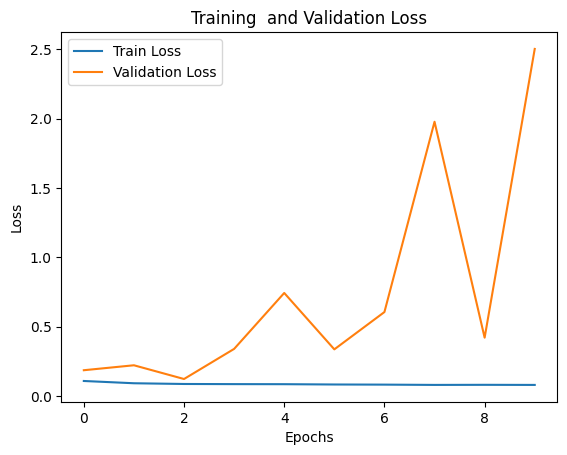

Making Predictions


/tmp/ipykernel_3094315/1509264483.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


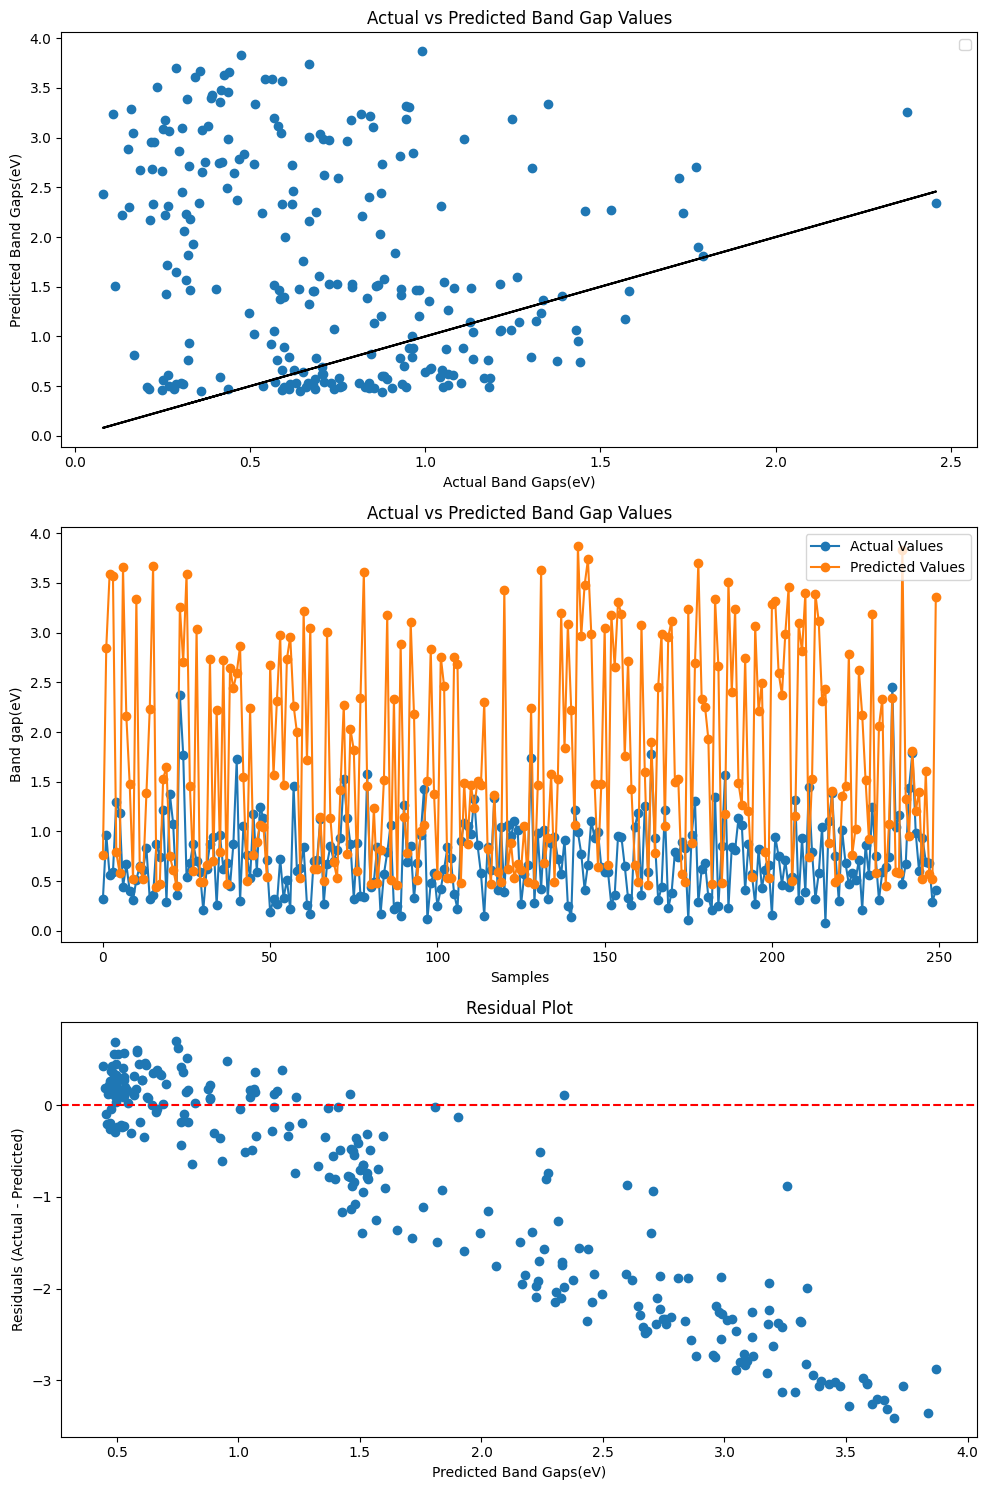

Mean Absolute Error: 1.1685
Mean Squared Error: 2.4425
R-squared: -14.2336


In [21]:
class GNNModel2(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, embed_dim, u_dim):
        super().__init__()

        # For the nodes and edges
        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        
        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean', batch_norm=True)
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean', batch_norm=True)

        # self.asapool = ASAPooling(hidden_dim, ratio=0.5)

        self.seq_combined= nn.Sequential(
            nn.Linear(hidden_dim,64), nn.ReLU(),
            nn.Linear(64,32), nn.ReLU(),
            nn.Linear(32,16), nn.ReLU(),
        )
        
        # =============
        # Global attributes
        self.global_embed = nn.Linear(u_dim, 16)

        # ================
        # Embedding
        self.defect_embed = nn.Embedding(119, 16, max_norm=1) 
        self.pad_embed = nn.Parameter(torch.randn(16))

        # ===============
        # Combine everything

        self.fc = nn.Sequential(
            nn.Linear(80, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

        
    def forward(self, data):
        x, edge_index, edge_attr, batch, u, ids, ratios, fe = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
            data.ids,
            data.ratios, 
            data.fe
        )
        x, edge_attr, u = (F.normalize(x), F.normalize(edge_attr), F.normalize(u))

        # =====================
        x = F.relu(self.conv0(x, edge_index, edge_attr))

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        '''while x.shape[0] != 1: # torch.Size([1,64]):
            x_pooled, edge_index_pooled, edge_weight_pooled, batch_pooled, perm = self.asapool(
                x=x, 
                edge_index=edge_index, 
                batch=batch
            )
            x, edge_index, batch = (x_pooled, edge_index_pooled, batch_pooled)'''

        x = global_mean_pool(x, batch)
        x = self.seq_combined(x) # [1,16]

        # =====================
        u = self.global_embed(u) # [1,16]

        # =====================

        ids_embed = self.defect_embed(ids) #[3, 16]
        weighted_emb = ids_embed * ratios.unsqueeze(1)

        if weighted_emb.shape[0] == 2:
            # Add padding
            to_add = self.pad_embed.unsqueeze(0) # .repeat(1, 1)
            
            weighted_emb = torch.cat([weighted_emb, to_add], dim=0)

        ir = weighted_emb.flatten().unsqueeze(0) # [1,48]
        # ir = global_mean_pool(weighted_emb,batch)

        # ========================
        # Combine everything

        x = torch.cat([x, u, ir], dim=1) # [1,48]
        # x = torch.cat([x,weighted_emb], dim=1) # [1,240]

        return self.fc(x)

        # PARAMETERIZE THE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2 = GNNModel2(NODE_DIM, EDGE_DIM, HIDDEN_DIM, EMBED_DIM, U_DIM).to(device)
# loss_fn = nn.MSELoss()
loss_fn = WeightedMSELoss(device)
epochs = 10

training_validating_testing(model2, loss_fn, epochs, device, predicting=True)

### Model 3

Training and Validating Model


  3%|▎         | 41/1500 [00:00<00:11, 131.03it/s]

Epoch 001, Train Loss: 0.1297, Val Loss: 1.8774


Epoch 002, Train Loss: 0.1023, Val Loss: 0.4249


Epoch 003, Train Loss: 0.0967, Val Loss: 0.9600


...

Epoch 007, Train Loss: 0.0855, Val Loss: 10.2143


Epoch 008, Train Loss: 0.0855, Val Loss: 3.6848


Epoch 009, Train Loss: 0.0838, Val Loss: 3.2554


Epoch 010, Train Loss: 0.0823, Val Loss: 0.1620
Testing Model


Test Loss: 0.1657


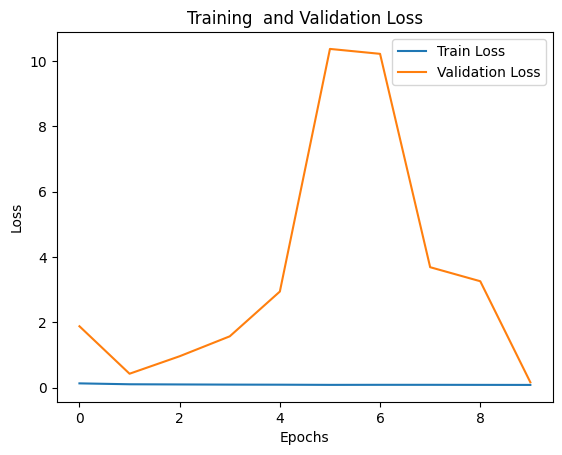

Making Predictions


/tmp/ipykernel_3094315/1509264483.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


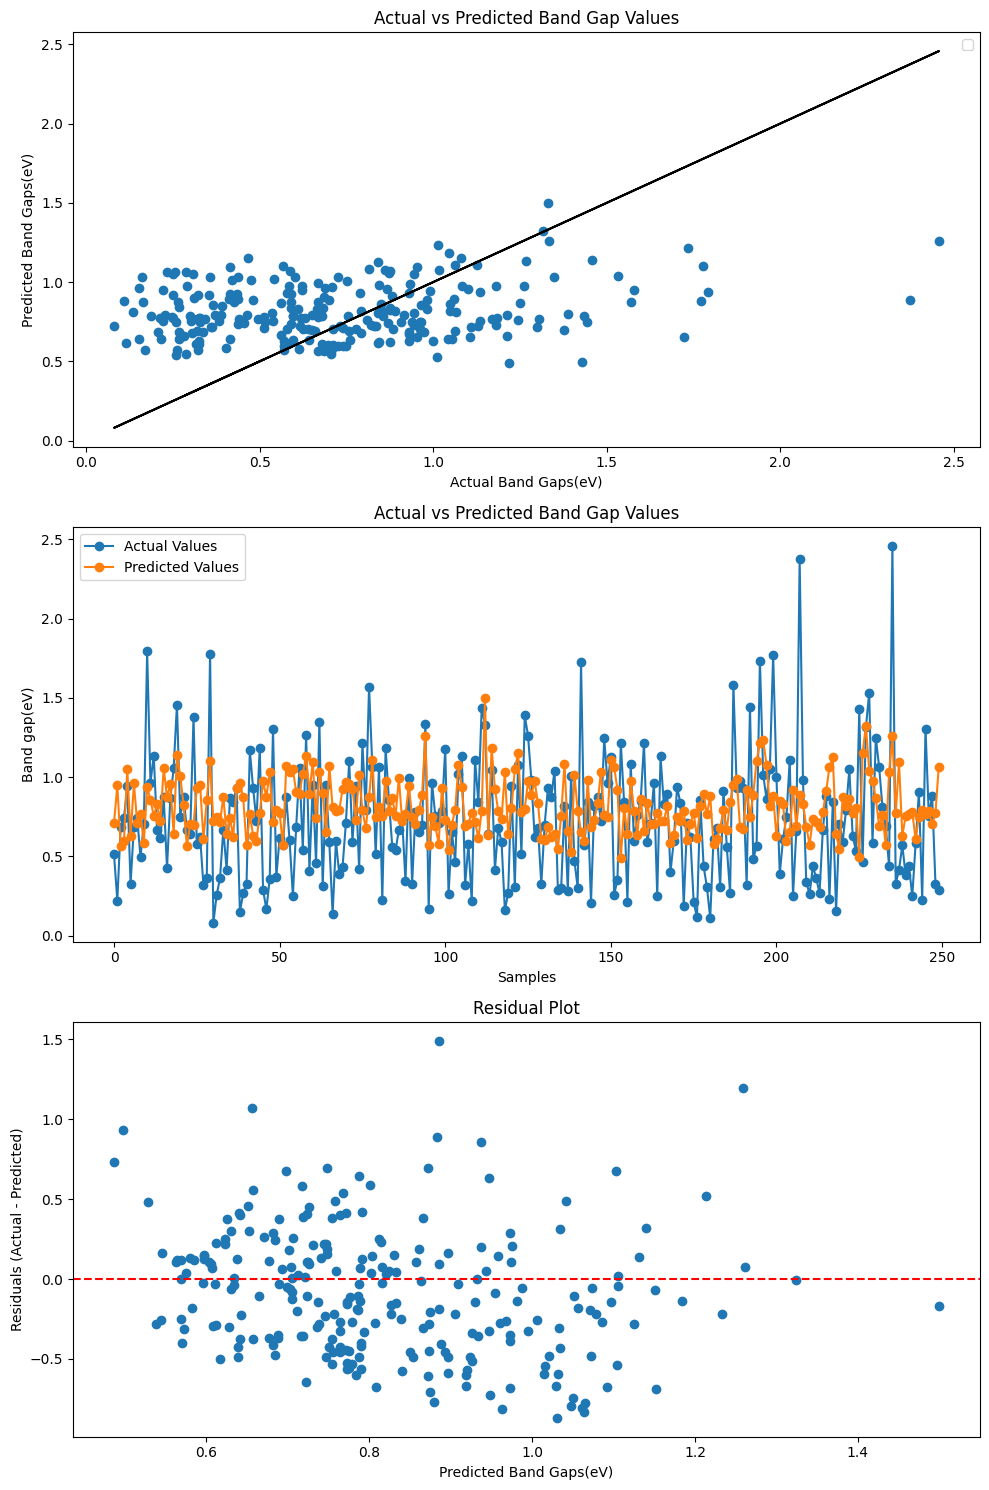

Mean Absolute Error: 0.3274
Mean Squared Error: 0.1657
R-squared: -0.0332


In [ ]:
class GNNModel3(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, embed_dim, u_dim, max_defects=3, defect_embed_dim=16):
        super().__init__()
        self.max_defects = max_defects
        self.defect_embed_dim = defect_embed_dim

        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)

        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean')
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv1_lin1 = nn.Linear(hidden_dim, 64)

        self.conv2 = CGConv(64, edge_dim, aggr='mean')
        self.bn2 = nn.BatchNorm1d(64)
        self.conv2_lin2 = nn.Linear(64, 32)

        self.global_embed = nn.Linear(u_dim, 32)

        self.defect_embed = nn.Embedding(119, defect_embed_dim, max_norm=1)
        self.pad_embed = nn.Parameter(torch.randn(defect_embed_dim))

        self.fc = nn.Sequential(
            nn.Linear(32 + 32 + max_defects * defect_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, ids, ratios = (
            data.x, data.edge_index, data.edge_attr, data.batch,
            data.u, data.ids, data.ratios,
        )
        x, edge_attr, u = (F.normalize(x), F.normalize(edge_attr), F.normalize(u))

        x = F.relu(self.bn0(self.conv0(x, edge_index, edge_attr)))
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.conv1_lin1(x))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.conv2_lin2(x))

        x = global_mean_pool(x, batch)  # [batch_size, 32]

        u = self.global_embed(u)  # [batch_size, 32]

        defect_batch = data.ids # adjust name to whatever follow_batch produces
        batch_size = x.size(0)
        weighted_emb = torch.zeros(batch_size, self.max_defects, self.defect_embed_dim, device=x.device)
        ids_embed = self.defect_embed(ids) * ratios.unsqueeze(1)  # [num_defects_total, 16]
        for b in range(batch_size):
            mask = defect_batch == b
            emb_b = ids_embed[mask]
            n = emb_b.size(0)
            if n >= self.max_defects:
                weighted_emb[b] = emb_b[: self.max_defects]
            else:
                weighted_emb[b, :n] = emb_b
                weighted_emb[b, n:] = self.pad_embed.unsqueeze(0)

        weighted_emb = weighted_emb.flatten(start_dim=1)  # [batch_size, max_defects*16]

        x = torch.cat([x, u], dim=1)
        return self.fc(x)

# PARAMETERIZE THE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model3 = GNNModel3(NODE_DIM, EDGE_DIM, HIDDEN_DIM, EMBED_DIM, U_DIM).to(device)
# loss_fn = nn.MSELoss()
loss_fn = WeightedMSELoss(device)
epochs = 10

training_validating_testing(model3, loss_fn, epochs, device, predicting=True)

### Model 4

Training and Validating Model


  3%|▎         | 44/1500 [00:00<00:06, 218.48it/s]

Epoch 001, Train Loss: 0.1303, Val Loss: 0.0904


Epoch 002, Train Loss: 0.0918, Val Loss: 0.0900


Epoch 003, Train Loss: 0.0849, Val Loss: 0.0905


...

Epoch 007, Train Loss: 0.0792, Val Loss: 0.0943


Epoch 008, Train Loss: 0.0777, Val Loss: 0.0922


Epoch 009, Train Loss: 0.0715, Val Loss: 0.0866


Epoch 010, Train Loss: 0.0722, Val Loss: 0.0840
Testing Model


Test Loss: 0.0962


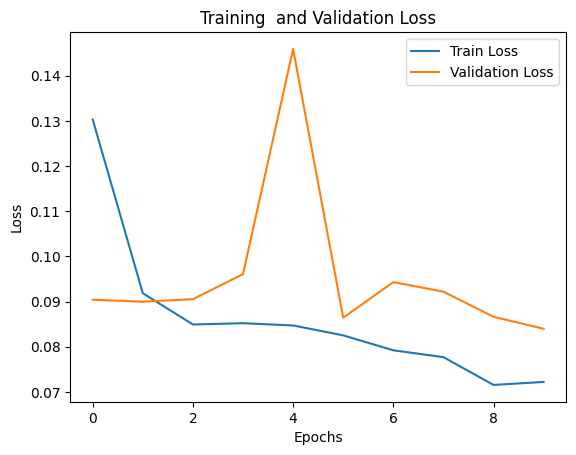

Making Predictions


/tmp/ipykernel_3094315/1509264483.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


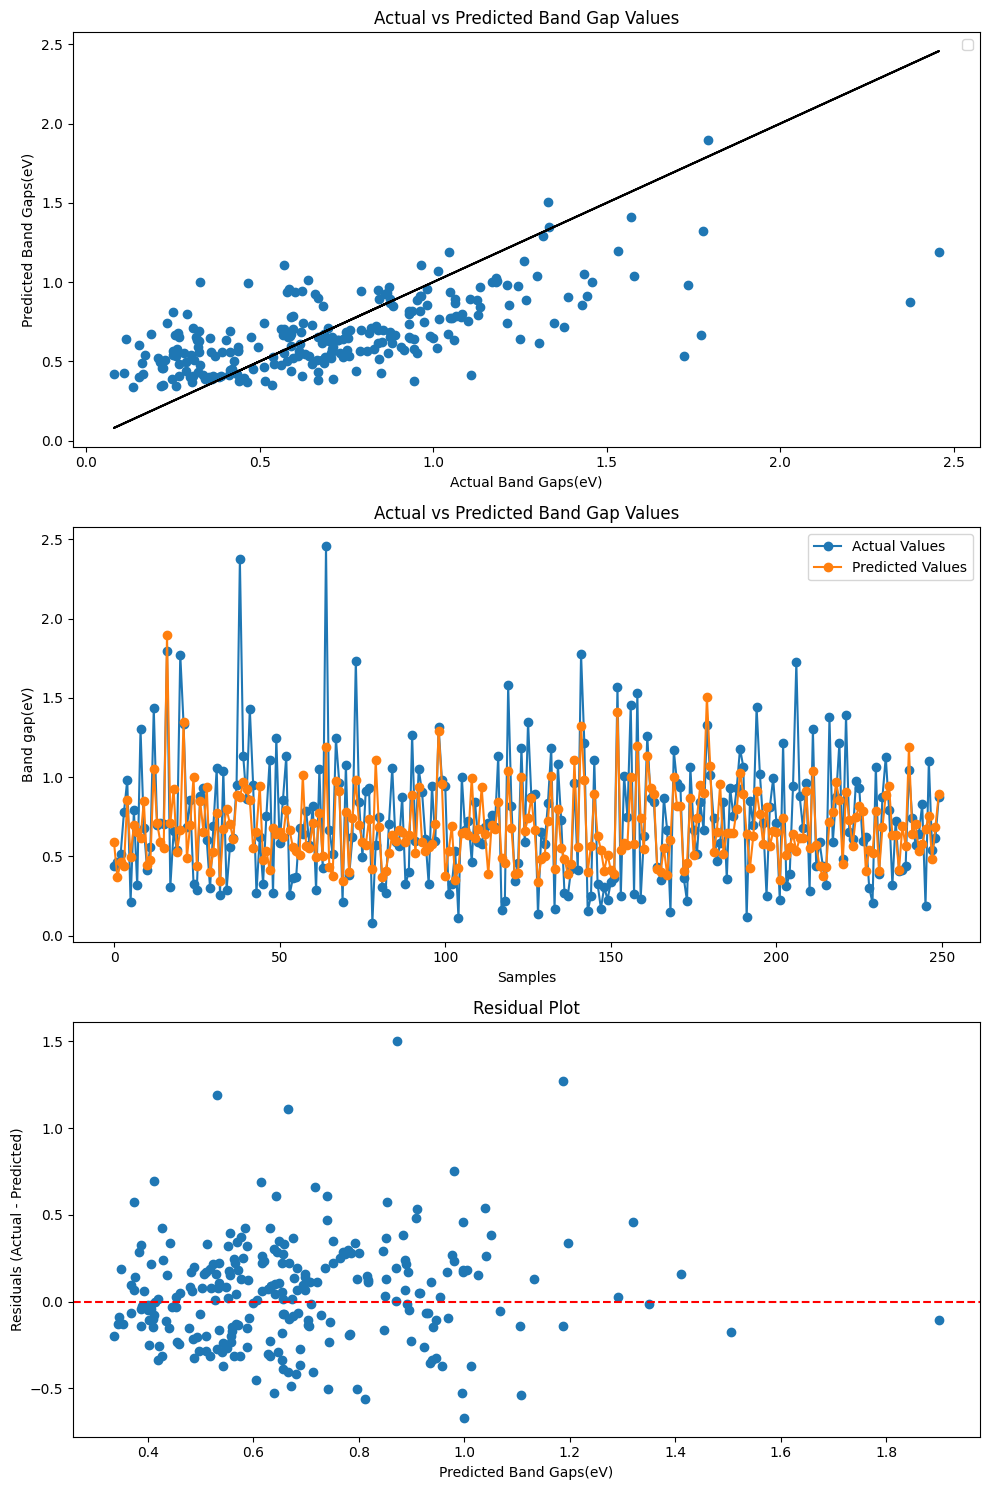

Mean Absolute Error: 0.2339
Mean Squared Error: 0.0962
R-squared: 0.4001


In [23]:
class GNNModel4(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()

        # For the edges
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim * hidden_dim)
        )

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        # self.conv1 = CGConv(hidden_dim, hidden_dim, aggr='mean')
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        x, edge_attr, u = (F.normalize(x), F.normalize(edge_attr), F.normalize(u))
        
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        the_return = self.fc(x)
        return the_return


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model4 = GNNModel4().to(device)
# loss_fn = nn.MSELoss()
loss_fn = WeightedMSELoss(device)
epochs = 10

training_validating_testing(model4, loss_fn, epochs, device, predicting=True)

### Model 5

Training and Validating Model


  3%|▎         | 38/1500 [00:00<00:07, 185.40it/s]

Epoch 001, Train Loss: 0.1371, Val Loss: 0.1042


Epoch 002, Train Loss: 0.1006, Val Loss: 0.0970


Epoch 003, Train Loss: 0.0926, Val Loss: 0.1027


...

Epoch 007, Train Loss: 0.0841, Val Loss: 0.1021


Epoch 008, Train Loss: 0.0807, Val Loss: 0.0859


Epoch 009, Train Loss: 0.0789, Val Loss: 0.0862


Epoch 010, Train Loss: 0.0771, Val Loss: 0.0869
Testing Model


Test Loss: 0.0971


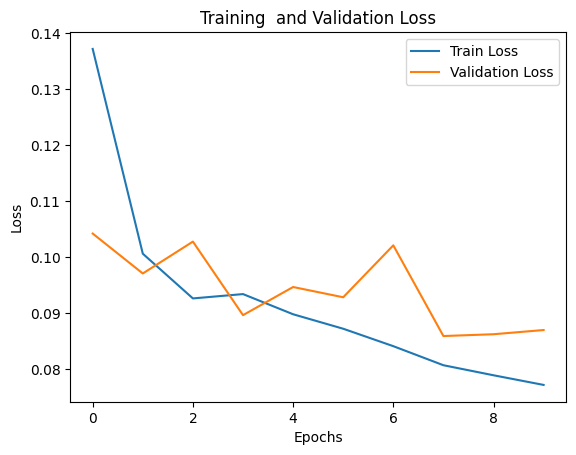

Making Predictions


/tmp/ipykernel_3094315/1509264483.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


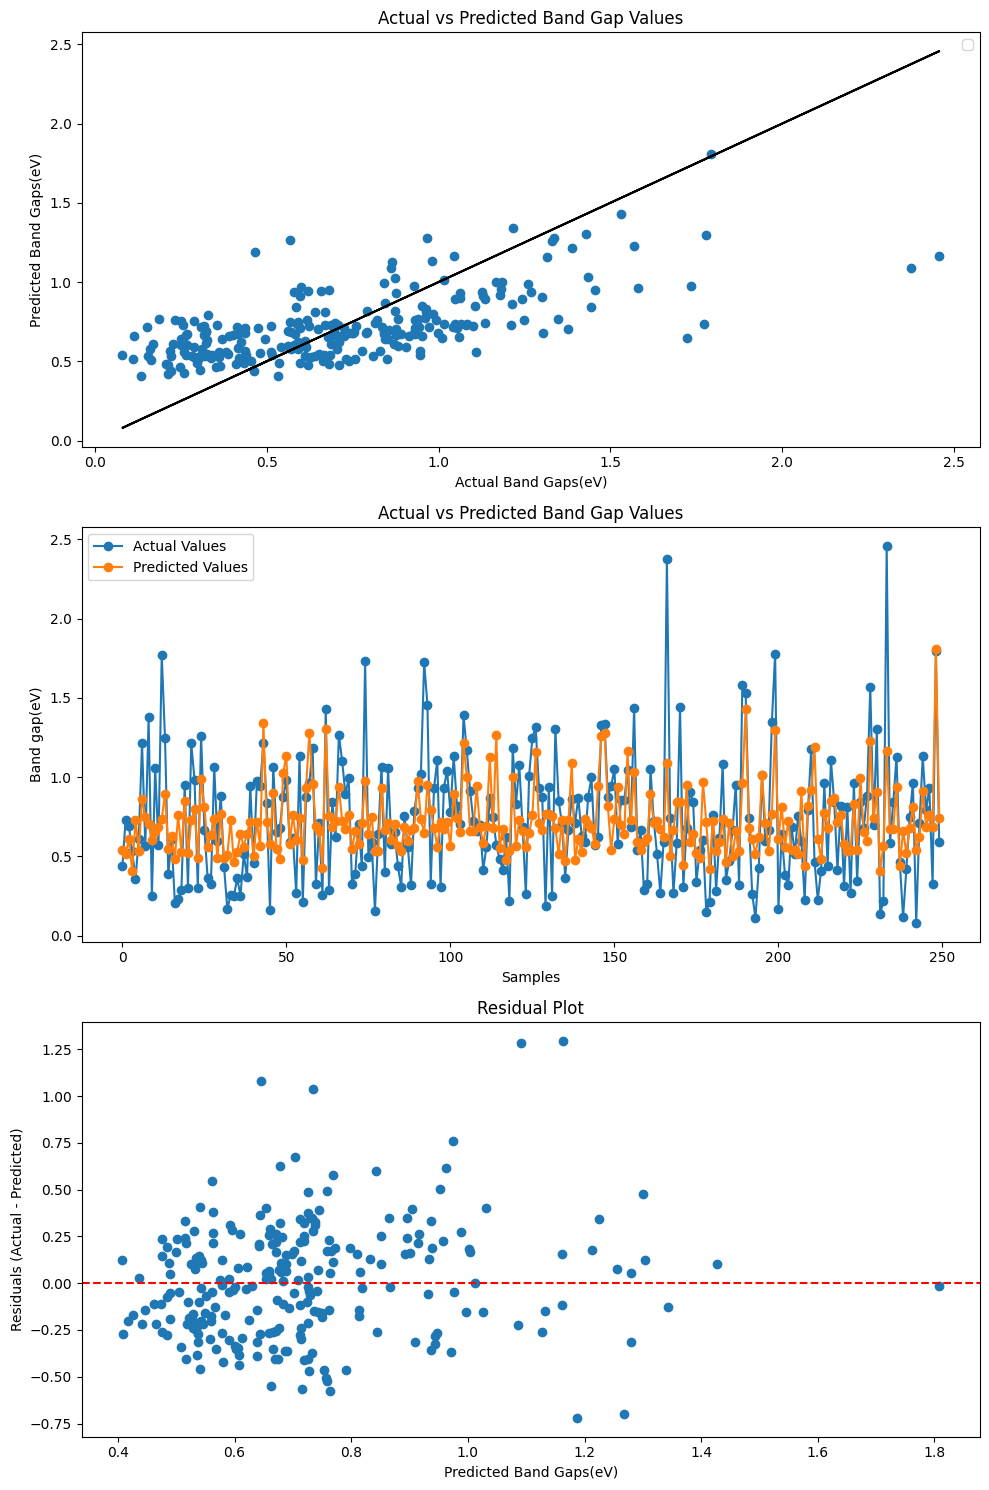

Mean Absolute Error: 0.2449
Mean Squared Error: 0.0971
R-squared: 0.3941


In [24]:
class GNNModel5(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, global_dim=U_DIM):
        super().__init__()

        # Edge network for NNConv: maps each edge_attr to a weight matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_dim * hidden_dim),
        )

        # First message-passing layer
        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_mlp, aggr='mean')

        # Second message-passing layer using CGConv
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')
        # self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean')

        # Embed the graph-level global features
        self.global_embed = nn.Linear(global_dim, embed_dim)

        # Final MLP head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Dropout(0.2),
            # NO ReLU here - allow both positive and negative outputs
            nn.Linear(32, 1), 
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        x, edge_attr, u = (F.normalize(x), F.normalize(edge_attr), F.normalize(u))

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        # x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)
        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model5 = GNNModel5().to(device)
# loss_fn = nn.MSELoss()
loss_fn = WeightedMSELoss(device)
epochs = 10

training_validating_testing(model5, loss_fn, epochs, device, predicting=True)